# Verificación de la Estacionariedad del Spread (Test ADF)

📥 Descargando datos históricos...


[*********************100%***********************]  4 of 4 completed


✅ Datos descargados: 1006 días hábiles.

🏗️ Construyendo el NAV sintético de la cesta...
📊 Generando gráficos de análisis...


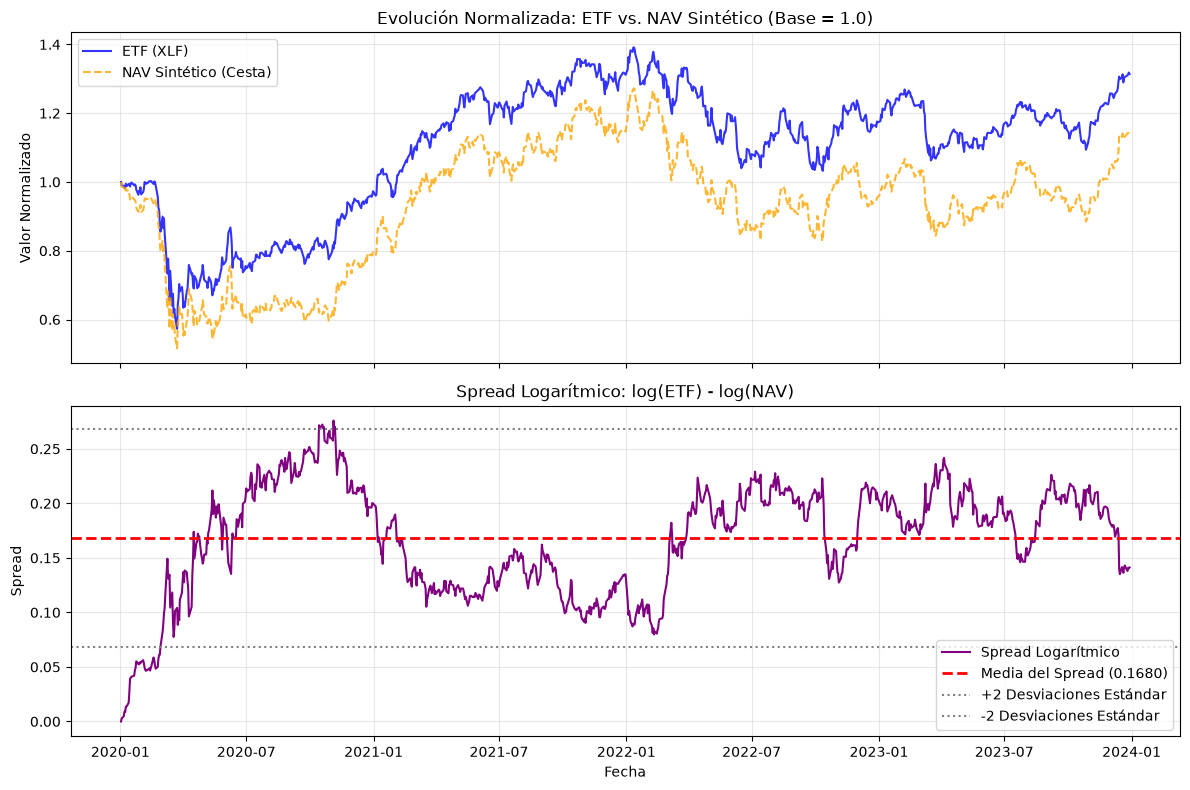

🔬 RESULTADOS DEL TEST DE ESTACIONARIEDAD (ADF)
Estadístico ADF:      -3.5809
p-valor:              0.0061

Valores críticos de referencia:
  1%: -3.4369
  5%: -2.8644
  10%: -2.5683

📝 INTERPRETACIÓN PEDAGÓGICA:
✅ CONCLUSIÓN: Rechazamos la hipótesis nula (p <= 0.05).
   El spread ES ESTACIONARIO.
   ➡️ Esto significa que las desviaciones son temporales y tienden a
      revertir a la media. El par es candidato para arbitraje estadístico.


In [1]:
# ==============================================================================
# EJERCICIO PRÁCTICO: Test de Estacionariedad (ADF) sobre Spread ETF vs. NAV
# ==============================================================================
# Objetivo: Demostrar cómo verificar estadísticamente si la diferencia entre 
# un ETF y su cesta de subyacentes revierte a la media (es estacionaria).
# 
# Requisitos: pip install yfinance pandas numpy matplotlib statsmodels
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. CONFIGURACIÓN DEL EJERCICIO
# Usamos XLF (Sector Financiero) y una cesta simplificada de sus principales bancos.
ETF_TICKER = 'XLF'
CESTA_TICKERS = ['JPM', 'BAC', 'WFC'] # Cesta simplificada para el ejercicio
FECHA_INICIO = '2020-01-01'
FECHA_FIN = '2023-12-31'

print("📥 Descargando datos históricos...")
# Descargamos los precios de cierre. 
# Nota: yfinance a veces devuelve columnas MultiIndex, las aplanamos por seguridad.
data = yf.download([ETF_TICKER] + CESTA_TICKERS, start=FECHA_INICIO, end=FECHA_FIN)['Close']
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Eliminamos días con datos faltantes para alinear las series temporales
data = data.dropna()
print(f"✅ Datos descargados: {len(data)} días hábiles.\n")

# 2. CONSTRUCCIÓN DEL NAV SINTÉTICO
print("🏗️ Construyendo el NAV sintético de la cesta...")
# Para este ejercicio pedagógico, usamos pesos igualitarios (1/3 para cada banco)
pesos = {ticker: 1.0 / len(CESTA_TICKERS) for ticker in CESTA_TICKERS}

# Normalizamos los precios para que todos empiecen en 1.0 en el primer día
nav_sintetico = pd.Series(0.0, index=data.index)
for ticker in CESTA_TICKERS:
    precio_normalizado = data[ticker] / data[ticker].iloc[0]
    nav_sintetico += pesos[ticker] * precio_normalizado

etf_normalizado = data[ETF_TICKER] / data[ETF_TICKER].iloc[0]

# 3. CÁLCULO DEL SPREAD LOGARÍTMICO
# Usamos logaritmos para medir la divergencia en términos porcentuales, no absolutos.
spread = np.log(etf_normalizado) - np.log(nav_sintetico)
spread = spread.dropna()

# 4. VISUALIZACIÓN
print("📊 Generando gráficos de análisis...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfico 1: Precios normalizados
ax1.plot(etf_normalizado, label=f'ETF ({ETF_TICKER})', color='blue', alpha=0.8)
ax1.plot(nav_sintetico, label='NAV Sintético (Cesta)', color='orange', alpha=0.8, linestyle='--')
ax1.set_title('Evolución Normalizada: ETF vs. NAV Sintético (Base = 1.0)')
ax1.set_ylabel('Valor Normalizado')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Spread logarítmico
ax2.plot(spread, label='Spread Logarítmico', color='purple', linewidth=1.5)
ax2.axhline(spread.mean(), color='red', linestyle='--', linewidth=2, label=f'Media del Spread ({spread.mean():.4f})')
ax2.axhline(spread.mean() + 2*spread.std(), color='gray', linestyle=':', label='+2 Desviaciones Estándar')
ax2.axhline(spread.mean() - 2*spread.std(), color='gray', linestyle=':', label='-2 Desviaciones Estándar')
ax2.set_title('Spread Logarítmico: log(ETF) - log(NAV)')
ax2.set_ylabel('Spread')
ax2.set_xlabel('Fecha')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller)
print("="*70)
print("🔬 RESULTADOS DEL TEST DE ESTACIONARIEDAD (ADF)")
print("="*70)

# Ejecutamos el test ADF. autolag='AIC' ayuda a seleccionar el número óptimo de lags.
resultado_adf = adfuller(spread, autolag='AIC')

estadistico = resultado_adf[0]
p_valor = resultado_adf[1]
valores_criticos = resultado_adf[4]

print(f"Estadístico ADF:      {estadistico:.4f}")
print(f"p-valor:              {p_valor:.4f}")
print("\nValores críticos de referencia:")
for nivel, valor in valores_criticos.items():
    print(f"  {nivel}: {valor:.4f}")

print("\n" + "="*70)
print("📝 INTERPRETACIÓN PEDAGÓGICA:")
print("="*70)

# Hipótesis Nula (H0): La serie temporal TIENE raíz unitaria (NO es estacionaria).
# Hipótesis Alternativa (H1): La serie temporal NO tiene raíz unitaria (ES estacionaria).

if p_valor <= 0.05:
    print("✅ CONCLUSIÓN: Rechazamos la hipótesis nula (p <= 0.05).")
    print("   El spread ES ESTACIONARIO.")
    print("   ➡️ Esto significa que las desviaciones son temporales y tienden a")
    print("      revertir a la media. El par es candidato para arbitraje estadístico.")
else:
    print("❌ CONCLUSIÓN: No podemos rechazar la hipótesis nula (p > 0.05).")
    print("   El spread NO ES ESTACIONARIO (tiene raíz unitaria).")
    print("   ➡️ Las desviaciones pueden ser permanentes o derivar con el tiempo.")
    print("      Operar este par sería especulación, no arbitraje.")
print("="*70)